# 02 - PREPROCESSING - PlantVillage

Notebook này được làm lại theo đúng hướng dẫn trong `README.md`.

Theo cấu trúc project, `02_preprocessing.ipynb` có nhiệm vụ chính:

- kiểm tra cấu trúc dữ liệu `train/val`;
- đếm số ảnh theo từng nhãn;
- tính tỉ lệ chia dữ liệu;
- chuẩn bị pipeline đọc ảnh để các notebook model sử dụng.

README cũng định hướng phần xử lý dữ liệu gồm:

- đọc ảnh;
- tạo dataset;
- resize;
- chuẩn hóa pixel;
- augmentation;
- chia batch.

Notebook **giữ nguyên split `train/val` có sẵn**, không tạo thêm test set và không chia lại dữ liệu.


# I. IMPORT VÀ CẤU HÌNH

In [47]:
from pathlib import Path
import os
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from dotenv import load_dotenv

SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device:", DEVICE)


PyTorch version: 2.14.0+cpu
Device: cpu


# II. XÁC ĐỊNH ĐƯỜNG DẪN DATASET

Cách lấy đường dẫn được giữ nhất quán với `01_eda.ipynb`:

1. Nếu `.env` có biến `DATA_DIR` thì dùng giá trị đó.
2. Nếu không có, mặc định tìm `PlantVillage` ở ngoài thư mục repo.

Với cấu trúc hiện tại:

```text
D:\Plant_disease\
├── plant-disease-classification\
│   └── notebooks\
└── PlantVillage\
    ├── train\
    └── val\
```

thì notebook sẽ tự tìm được dataset mà không cần hard-code toàn bộ đường dẫn.


In [48]:
load_dotenv()

PROJECT_DIR = Path.cwd()

if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

DATA_DIR = Path(
    os.getenv("DATA_DIR")
    or PROJECT_DIR.parent / "PlantVillage"
).resolve()

TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"

OUTPUT_DIR = PROJECT_DIR / "outputs" / "results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR :", PROJECT_DIR)
print("DATA_DIR    :", DATA_DIR)
print("TRAIN exists:", TRAIN_DIR.exists())
print("VAL exists  :", VAL_DIR.exists())

if not TRAIN_DIR.exists():
    raise FileNotFoundError(
        f"Không tìm thấy thư mục train tại: {TRAIN_DIR}"
    )

if not VAL_DIR.exists():
    raise FileNotFoundError(
        f"Không tìm thấy thư mục val tại: {VAL_DIR}"
    )


PROJECT_DIR : d:\Plant_disease\plant-disease-classification
DATA_DIR    : D:\Plant_disease\PlantVillage
TRAIN exists: True
VAL exists  : True


# III. KIỂM TRA CẤU TRÚC `train/val`

In [49]:
train_classes = sorted(
    folder.name
    for folder in TRAIN_DIR.iterdir()
    if folder.is_dir()
)

val_classes = sorted(
    folder.name
    for folder in VAL_DIR.iterdir()
    if folder.is_dir()
)

print("Số class train:", len(train_classes))
print("Số class val  :", len(val_classes))

only_train = sorted(set(train_classes) - set(val_classes))
only_val = sorted(set(val_classes) - set(train_classes))

print("\nClass chỉ có trong train:", only_train)
print("Class chỉ có trong val  :", only_val)

if train_classes != val_classes:
    raise ValueError(
        "Danh sách class giữa train và val không giống nhau."
    )


Số class train: 38
Số class val  : 38

Class chỉ có trong train: []
Class chỉ có trong val  : []


Kết quả mong đợi theo README:

- `train`: 38 class
- `val`: 38 class
- không có class chỉ xuất hiện ở một split.


# IV. ĐẾM SỐ ẢNH THEO TỪNG NHÃN

In [50]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}


def count_images(class_dir):
    return sum(
        1
        for path in class_dir.rglob("*")
        if path.is_file()
        and path.suffix.lower() in IMAGE_EXTS
    )


train_counts = {
    class_name: count_images(TRAIN_DIR / class_name)
    for class_name in train_classes
}

val_counts = {
    class_name: count_images(VAL_DIR / class_name)
    for class_name in val_classes
}

class_distribution = pd.DataFrame({
    "class_name": train_classes,
    "train_count": [
        train_counts[class_name]
        for class_name in train_classes
    ],
    "val_count": [
        val_counts[class_name]
        for class_name in train_classes
    ]
})

class_distribution["total"] = (
    class_distribution["train_count"]
    + class_distribution["val_count"]
)

class_distribution["train_ratio"] = (
    class_distribution["train_count"]
    / class_distribution["total"]
    * 100
).round(2)

class_distribution["val_ratio"] = (
    class_distribution["val_count"]
    / class_distribution["total"]
    * 100
).round(2)

class_distribution.head()


,class_name,train_count,val_count,total,train_ratio,val_ratio
0,Apple___Apple_scab,504,126,630,80.00,20.00
1,Apple___Black_rot,496,125,621,79.87,20.13
2,Apple___Cedar_apple_rust,220,55,275,80.00,20.00
3,Apple___healthy,1316,329,1645,80.00,20.00
4,Blueberry___healthy,1202,300,1502,80.03,19.97


In [51]:
num_train = int(class_distribution["train_count"].sum())
num_val = int(class_distribution["val_count"].sum())
total_images = num_train + num_val

print(f"Train images      : {num_train:,}")
print(f"Validation images : {num_val:,}")
print(f"Total images      : {total_images:,}")
print(f"Number of classes : {len(train_classes)}")

print(f"\nTrain ratio      : {num_train / total_images:.2%}")
print(f"Validation ratio : {num_val / total_images:.2%}")


Train images      : 43,444
Validation images : 10,861
Total images      : 54,305
Number of classes : 38

Train ratio      : 80.00%
Validation ratio : 20.00%


Theo README, kết quả mong đợi là khoảng:

```text
Train images      : 43,444
Validation images : 10,861
Total images      : 54,305
Number of classes : 38

Train ratio       : 80%
Validation ratio  : 20%
```

Nếu số liệu trên máy khác một chút, hãy ưu tiên số liệu thực tế notebook đếm được.


In [52]:
display(
    class_distribution.sort_values(
        "total",
        ascending=False
    )
)


,class_name,train_count,val_count,total,train_ratio,val_ratio
15,Orange___Haunglongbing_(Citrus_greening),4405,1102,5507,79.99,20.01
35,Tomato___Tomato_Yellow_Leaf_Curl_Virus,4286,1071,5357,80.01,19.99
24,Soybean___healthy,4072,1018,5090,80.00,20.00
16,Peach___Bacterial_spot,1838,459,2297,80.02,19.98
28,Tomato___Bacterial_spot,1702,425,2127,80.02,19.98
30,Tomato___Late_blight,1527,382,1909,79.99,20.01
25,Squash___Powdery_mildew,1468,367,1835,80.00,20.00
32,Tomato___Septoria_leaf_spot,1417,354,1771,80.01,19.99
33,Tomato___Spider_mites Two-spotted_spider_mite,1341,335,1676,80.01,19.99
3,Apple___healthy,1316,329,1645,80.00,20.00


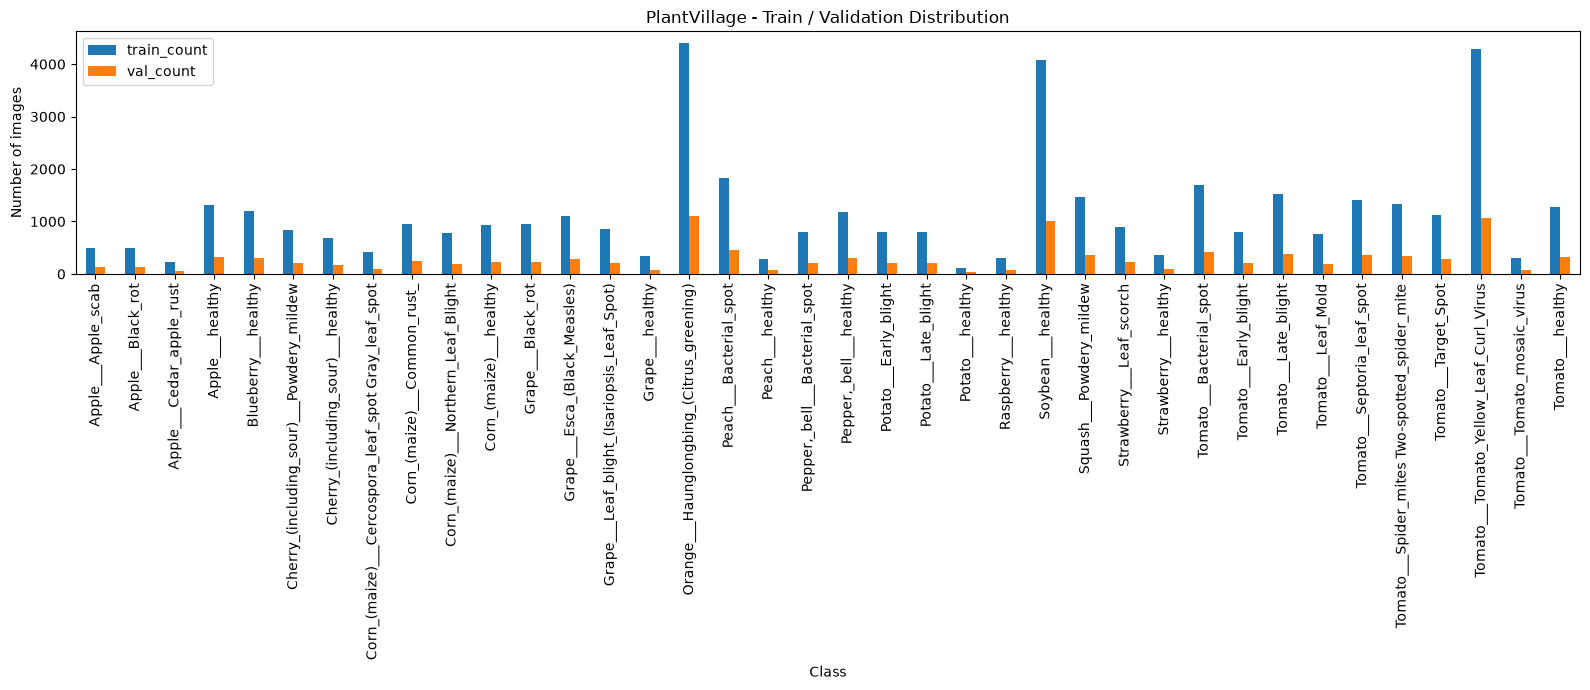

In [53]:
plot_df = class_distribution.set_index("class_name")

ax = plot_df[
    ["train_count", "val_count"]
].plot(
    kind="bar",
    figsize=(16, 7)
)

ax.set_title("PlantVillage - Train / Validation Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Number of images")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


# V. IMAGE TRANSFORMS

README yêu cầu pipeline có resize, chuẩn hóa pixel và augmentation nhưng không quy định phép augmentation cụ thể.

Trong notebook này:

### Train
- chuyển ảnh về RGB;
- resize về `224 x 224`;
- lật ngang ngẫu nhiên;
- xoay nhẹ;
- chuyển thành tensor;
- `ToTensor()` đưa pixel từ `[0,255]` về `[0,1]`.

### Validation
- chuyển RGB;
- resize `224 x 224`;
- `ToTensor()`;
- **không augmentation**.

Việc không augmentation validation giúp quá trình đánh giá ổn định.


In [54]:
train_transform = transforms.Compose([
    transforms.Lambda(
        lambda image: image.convert("RGB")
    ),
    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),
    transforms.RandomHorizontalFlip(
        p=0.5
    ),
    transforms.RandomRotation(
        degrees=10
    ),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Lambda(
        lambda image: image.convert("RGB")
    ),
    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),
    transforms.ToTensor(),
])

print("Train transform:")
print(train_transform)

print("\nValidation transform:")
print(val_transform)


Train transform:
Compose(
    Lambda()
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
)

Validation transform:
Compose(
    Lambda()
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


# VI. TẠO DATASET

PlantVillage đã có đúng cấu trúc thư mục mà `torchvision.datasets.ImageFolder` yêu cầu:

```text
train/
    class_1/
    class_2/
    ...

val/
    class_1/
    class_2/
    ...
```

Vì vậy không cần viết custom class `PlantVillage`.


In [55]:
train_dataset = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=VAL_DIR,
    transform=val_transform
)

class_names = train_dataset.classes
class_to_idx = train_dataset.class_to_idx
idx_to_class = {
    index: class_name
    for class_name, index in class_to_idx.items()
}

NUM_CLASSES = len(class_names)

print("Train dataset     :", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Number of classes :", NUM_CLASSES)

if train_dataset.class_to_idx != val_dataset.class_to_idx:
    raise ValueError(
        "Mapping class giữa train và val không giống nhau."
    )


Train dataset     : 43444
Validation dataset: 10861
Number of classes : 38


In [56]:
mapping_df = pd.DataFrame({
    "label": list(range(NUM_CLASSES)),
    "class_name": class_names
})

display(mapping_df)


,label,class_name
0,0,Apple___Apple_scab
1,1,Apple___Black_rot
2,2,Apple___Cedar_apple_rust
3,3,Apple___healthy
4,4,Blueberry___healthy
5,5,Cherry_(including_sour)___Powdery_mildew
6,6,Cherry_(including_sour)___healthy
7,7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...
8,8,Corn_(maize)___Common_rust_
9,9,Corn_(maize)___Northern_Leaf_Blight


# VII. TẠO DATALOADER / CHIA BATCH

In [57]:
# num_workers=0 là lựa chọn ổn định cho Jupyter/VS Code trên Windows.

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Batch size        :", BATCH_SIZE)
print("Train batches     :", len(train_loader))
print("Validation batches:", len(val_loader))


Batch size        : 32
Train batches     : 1358
Validation batches: 340


# VIII. KIỂM TRA KẾT QUẢ PREPROCESSING

In [58]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

print("\nImage dtype:", images.dtype)
print("Label dtype:", labels.dtype)

print("\nPixel min:", images.min().item())
print("Pixel max:", images.max().item())

print("\nLabel min:", labels.min().item())
print("Label max:", labels.max().item())


Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])

Image dtype: torch.float32
Label dtype: torch.int64

Pixel min: 0.0
Pixel max: 1.0

Label min: 0
Label max: 37


Kết quả mong đợi:

```text
Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])

Pixel min: >= 0
Pixel max: <= 1

Label nằm trong khoảng 0 ... 37
```


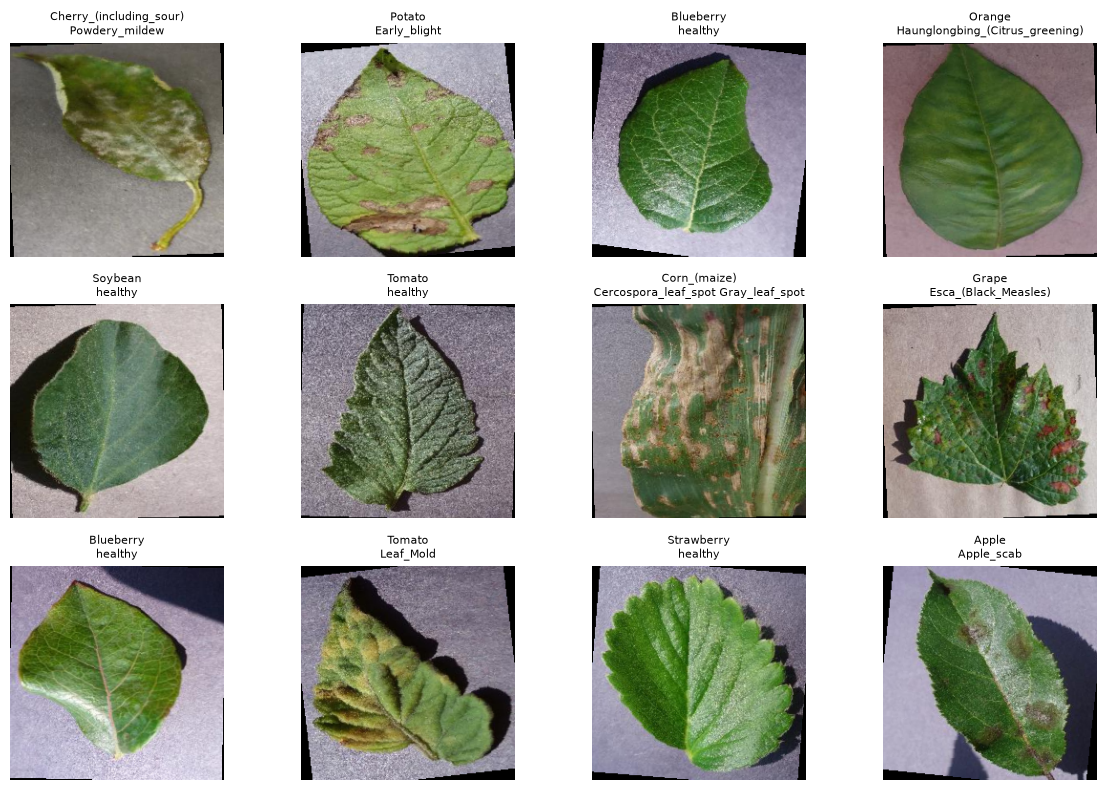

In [59]:
plt.figure(figsize=(12, 8))

num_images = min(12, len(images))

for i in range(num_images):
    image = images[i].permute(1, 2, 0).numpy()
    label = int(labels[i].item())

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title(
        class_names[label].replace("___", "\n"),
        fontsize=8
    )
    plt.axis("off")

plt.tight_layout()
plt.show()


# IX. LƯU KẾT QUẢ PREPROCESSING

Theo cấu trúc README, kết quả sinh ra trong quá trình chạy project được lưu trong `outputs/`.

Notebook lưu:

- `class_distribution.csv`: số ảnh của từng class;
- `class_to_idx.json`: mapping tên class → label số;
- `preprocessing_config.json`: cấu hình preprocessing.


In [60]:
distribution_path = OUTPUT_DIR / "class_distribution.csv"
mapping_path = OUTPUT_DIR / "class_to_idx.json"
config_path = OUTPUT_DIR / "preprocessing_config.json"

class_distribution.to_csv(
    distribution_path,
    index=False
)

with open(
    mapping_path,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        class_to_idx,
        file,
        ensure_ascii=False,
        indent=2
    )

preprocessing_config = {
    "framework": "PyTorch",
    "dataset_path": str(DATA_DIR),
    "train_size": len(train_dataset),
    "val_size": len(val_dataset),
    "total_size": (
        len(train_dataset)
        + len(val_dataset)
    ),
    "num_classes": NUM_CLASSES,
    "image_size": [
        IMG_SIZE,
        IMG_SIZE
    ],
    "channels": 3,
    "pixel_range": [
        0.0,
        1.0
    ],
    "batch_size": BATCH_SIZE,
    "seed": SEED,
    "train_augmentation": [
        "RandomHorizontalFlip(p=0.5)",
        "RandomRotation(degrees=10)"
    ],
    "validation_augmentation": []
}

with open(
    config_path,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        preprocessing_config,
        file,
        ensure_ascii=False,
        indent=2
    )

print("Saved:", distribution_path)
print("Saved:", mapping_path)
print("Saved:", config_path)


Saved: d:\Plant_disease\plant-disease-classification\outputs\results\class_distribution.csv
Saved: d:\Plant_disease\plant-disease-classification\outputs\results\class_to_idx.json
Saved: d:\Plant_disease\plant-disease-classification\outputs\results\preprocessing_config.json


# X. PREPROCESSING SUMMARY

In [61]:
print("=" * 55)
print("PREPROCESSING SUMMARY")
print("=" * 55)

print(f"Dataset path      : {DATA_DIR}")
print(f"Training images   : {len(train_dataset):,}")
print(f"Validation images : {len(val_dataset):,}")
print(
    f"Total images      : "
    f"{len(train_dataset) + len(val_dataset):,}"
)
print(f"Number of classes : {NUM_CLASSES}")

total = len(train_dataset) + len(val_dataset)

print(
    f"Train ratio       : "
    f"{len(train_dataset) / total:.2%}"
)

print(
    f"Validation ratio  : "
    f"{len(val_dataset) / total:.2%}"
)

print(f"Image size        : {IMG_SIZE} x {IMG_SIZE}")
print(f"Batch size        : {BATCH_SIZE}")
print("Channels          : RGB (3)")
print("Pixel range       : [0, 1]")
print("Train augmentation: Yes")
print("Val augmentation  : No")


PREPROCESSING SUMMARY
Dataset path      : D:\Plant_disease\PlantVillage
Training images   : 43,444
Validation images : 10,861
Total images      : 54,305
Number of classes : 38
Train ratio       : 80.00%
Validation ratio  : 20.00%
Image size        : 224 x 224
Batch size        : 32
Channels          : RGB (3)
Pixel range       : [0, 1]
Train augmentation: Yes
Val augmentation  : No


## Output dùng cho các notebook model

Sau khi chạy notebook từ trên xuống, các biến chính có thể dùng tiếp là:

```python
train_dataset
val_dataset

train_loader
val_loader

NUM_CLASSES
class_names
class_to_idx
idx_to_class

DEVICE
```

Ví dụ:

```python
images, labels = next(iter(train_loader))

images = images.to(DEVICE)
labels = labels.to(DEVICE)
```

### Pipeline cuối cùng

```text
PlantVillage
│
├── train
│   └── RGB
│       → Resize 224×224
│       → Augmentation
│       → ToTensor / [0,1]
│       → Batch 32
│
└── val
    └── RGB
        → Resize 224×224
        → ToTensor / [0,1]
        → Batch 32
```

Notebook không thêm bước chia dữ liệu mới vì dataset đã có sẵn `train/val`.
